In [154]:
import numpy as np
import matplotlib.pyplot as plt

In [155]:
class MonteCarlo():
    def __init__(self, size=1000000, min=0, max=1):
        self.size = size
        self.min = min
        self.max = max
        self.D = None
        self.sample_x = None
        self.sample_y = None

    def sampler(self):
        self.sample_x = np.random.uniform(self.min, self.max, self.size)
        self.sample_y = np.random.uniform(self.min, self.max, self.size)

In [156]:
class MonteCarloSquare(MonteCarlo):
    def __init__(self, x_min=0, x_max=1, y_min=0, y_max=1, size=1000000):
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        super().__init__(size=size)

    def indicatorFunction(self):
        self.D = []
        for x, y in zip(self.sample_x, self.sample_y):
            if (self.x_min < x < self.x_max) & (self.y_min < y < self.y_max):
                self.D.append(1)
            else:
                self.D.append(0)

    def occupiedArea(self):
        self.sampler()
        self.indicatorFunction()
        P = sum(self.D) / len(self.D)
        return P

In [157]:
class MonteCarloCircle(MonteCarlo):

    def indicatorFunction(self):
        self.D = []
        for x, y in zip(self.sample_x, self.sample_y):
            if (x**2 + y**2 < 1):
                self.D.append(1)
            else:
                self.D.append(0)

    def occupiedArea(self):
        self.sampler()
        self.indicatorFunction()
        P = sum(self.D) / len(self.D)
        return P

In [158]:
square = MonteCarloSquare(x_min=0, x_max=0.2, y_min=0, y_max=0.2)
square2 = MonteCarloSquare(x_min=0, x_max=0.2, y_min=0.8, y_max=1)

print(square.occupiedArea())
print(square2.occupiedArea())

0.040178
0.040007


In [159]:
circ = MonteCarloCircle()
circ.occupiedArea()

0.785579

np.int64(1)

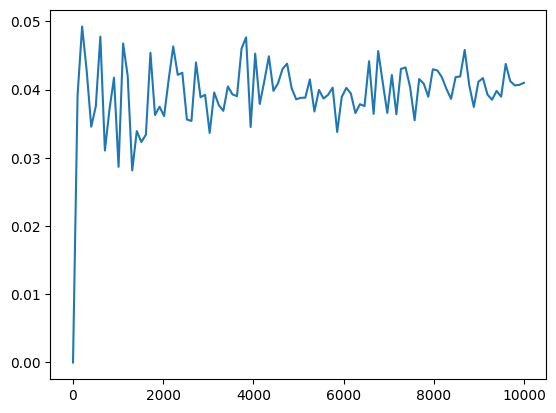

In [160]:
Ns = np.linspace(1,10000, 100).astype(int)

Ps = []
for N in Ns:
    square = MonteCarloSquare(size=N, x_min=0, x_max=0.2, y_min=0, y_max=0.2)
    Ps.append(square.occupiedArea())

plt.plot(Ns, Ps)
Ns[0]